# 🤖 Notebook 04 — Modelling

**Purpose:** Train and evaluate 10 classification models on the engineered feature matrix. Every model uses the same evaluation function (`src/evaluation.py`), 5-fold cross-validation for stability, and final evaluation on the held-out temporal test set.

**Random state 42 everywhere for reproducibility.**

## Setup

In [2]:
import os, sys, json, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Add src to path
sys.path.insert(0, os.path.abspath("../src"))
from evaluation import evaluate_model

OUTPUTS_PATH = "../outputs"
FIGURES_PATH = os.path.join(OUTPUTS_PATH, "figures")
MODELS_PATH  = os.path.join(OUTPUTS_PATH, "models")
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Load feature matrices
X_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, "X_train.parquet"))
X_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, "X_test.parquet"))
y_train = pd.read_parquet(os.path.join(OUTPUTS_PATH, "y_train.parquet"))["success"]
y_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, "y_test.parquet"))["success"]

with open(os.path.join(OUTPUTS_PATH, "feature_cols.json")) as f:
    FEATURE_COLS = json.load(f)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train balance: {y_train.mean()*100:.1f}% success")
print(f"y_test  balance: {y_test.mean()*100:.1f}% success")
print(f"\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS[:10]} ...")

RANDOM_STATE = 42
SUCCESS_COLOR = "#3B82F6"
FAILURE_COLOR = "#EF4444"


X_train: (150743, 52)  X_test: (37686, 52)
y_train balance: 60.7% success
y_test  balance: 69.2% success

Features (52): ['log_goal', 'duration_days', 'prep_days', 'has_video', 'blurb_length', 'name_length', 'blurb_word_count', 'name_has_number', 'goal_is_round', 'is_usd'] ...


## Cross-Validation Setup

We use **StratifiedKFold (k=5)** on the training set for all cross-validation. Stratified folds preserve the class balance in each fold — important here since our classes are imbalanced (~37% success).

In [3]:
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import f1_score, roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_report(model, X, y, model_name):
    f1_scores  = cross_val_score(model, X, y, cv=skf, scoring="f1", n_jobs=-1)
    auc_scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
    print(f"  [{model_name}] CV F1 : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"  [{model_name}] CV AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    return f1_scores.mean(), auc_scores.mean()

print("Cross-validation setup: 5-fold StratifiedKFold, random_state=42")


Cross-validation setup: 5-fold StratifiedKFold, random_state=42


## Model 1 — Logistic Regression (Baseline)

Logistic Regression is the **mandatory interpretable baseline**. If ensemble methods don't significantly outperform it, that tells us the decision boundary is approximately linear — a valuable finding in itself. We use `class_weight='balanced'` to compensate for the class imbalance.

Training Logistic Regression...
  [Logistic Regression] CV F1 : 0.8283 ± 0.0019
  [Logistic Regression] CV AUC: 0.8903 ± 0.0016

  Model: Logistic Regression
  Accuracy        : 0.7845
  Precision       : 0.8238
  Recall          : 0.8758
  F1 (binary)     : 0.8490
  F1 (macro)      : 0.7363
  ROC-AUC         : 0.8285
  PR-AUC          : 0.9086

              precision    recall  f1-score   support

           0       0.68      0.58      0.62     11613
           1       0.82      0.88      0.85     26073

    accuracy                           0.78     37686
   macro avg       0.75      0.73      0.74     37686
weighted avg       0.78      0.78      0.78     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv


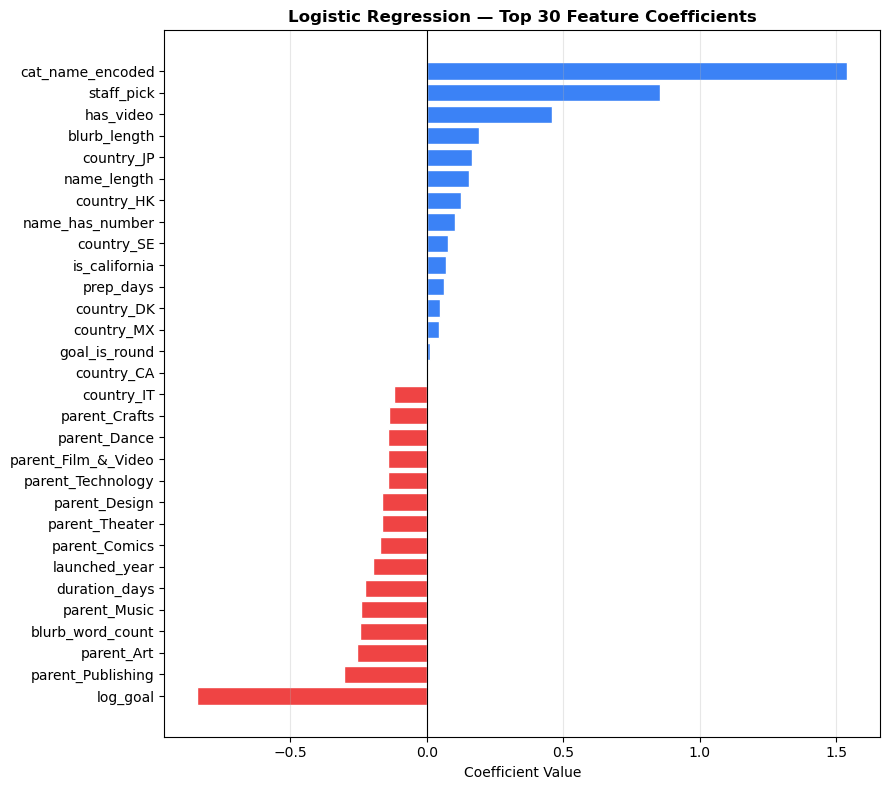


Top positive features (predict success):
country_JP          0.165399
blurb_length        0.192087
has_video           0.459260
staff_pick          0.855193
cat_name_encoded    1.540854

Top negative features (predict failure):
log_goal            -0.841303
parent_Publishing   -0.302678
parent_Art          -0.255082
blurb_word_count    -0.244136
parent_Music        -0.240416


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

print("Training Logistic Regression...")
cv_report(lr_pipeline, X_train, y_train, "Logistic Regression")
lr_pipeline.fit(X_train, y_train)
lr_results = evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression",
                             figures_dir=FIGURES_PATH)

# Save model
with open(os.path.join(MODELS_PATH, "logistic_regression.pkl"), "wb") as f:
    pickle.dump(lr_pipeline, f)

# Feature importance: LR coefficients
lr_model = lr_pipeline.named_steps["model"]
coefs    = pd.Series(lr_model.coef_[0], index=FEATURE_COLS).sort_values()
top_pos  = coefs.tail(15)
top_neg  = coefs.head(15)
plot_coefs = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(9, 8))
colors = [SUCCESS_COLOR if v > 0 else FAILURE_COLOR for v in plot_coefs]
ax.barh(plot_coefs.index, plot_coefs.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression — Top 30 Feature Coefficients", fontweight="bold")
ax.set_xlabel("Coefficient Value")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "lr_coefficients.png"), dpi=150, bbox_inches="tight")
plt.show()
print("\nTop positive features (predict success):")
print(top_pos.tail(5).to_string())
print("\nTop negative features (predict failure):")
print(top_neg.head(5).to_string())


## Model 2 — Decision Tree

Decision Trees are highly interpretable — we can literally read the rules the model learned. We tune `max_depth` via cross-validation and visualise the tree at depth=3 for clarity.

  max_depth=3    : AUC=0.8384 ± 0.0014
  max_depth=5    : AUC=0.8746 ± 0.0013
  max_depth=7    : AUC=0.8906 ± 0.0012
  max_depth=10   : AUC=0.8963 ± 0.0018
  max_depth=15   : AUC=0.8575 ± 0.0016
  max_depth=None : AUC=0.7544 ± 0.0023

Best max_depth: 10


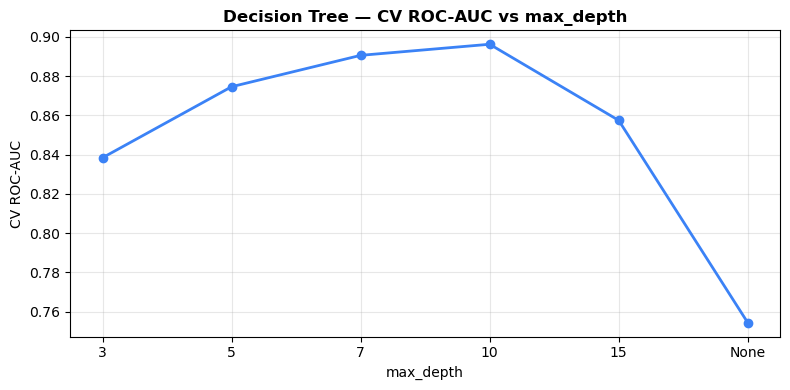


  Model: Decision Tree
  Accuracy        : 0.7955
  Precision       : 0.8684
  Recall          : 0.8302
  F1 (binary)     : 0.8489
  F1 (macro)      : 0.7663
  ROC-AUC         : 0.8454
  PR-AUC          : 0.9005

              precision    recall  f1-score   support

           0       0.65      0.72      0.68     11613
           1       0.87      0.83      0.85     26073

    accuracy                           0.80     37686
   macro avg       0.76      0.77      0.77     37686
weighted avg       0.80      0.80      0.80     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv


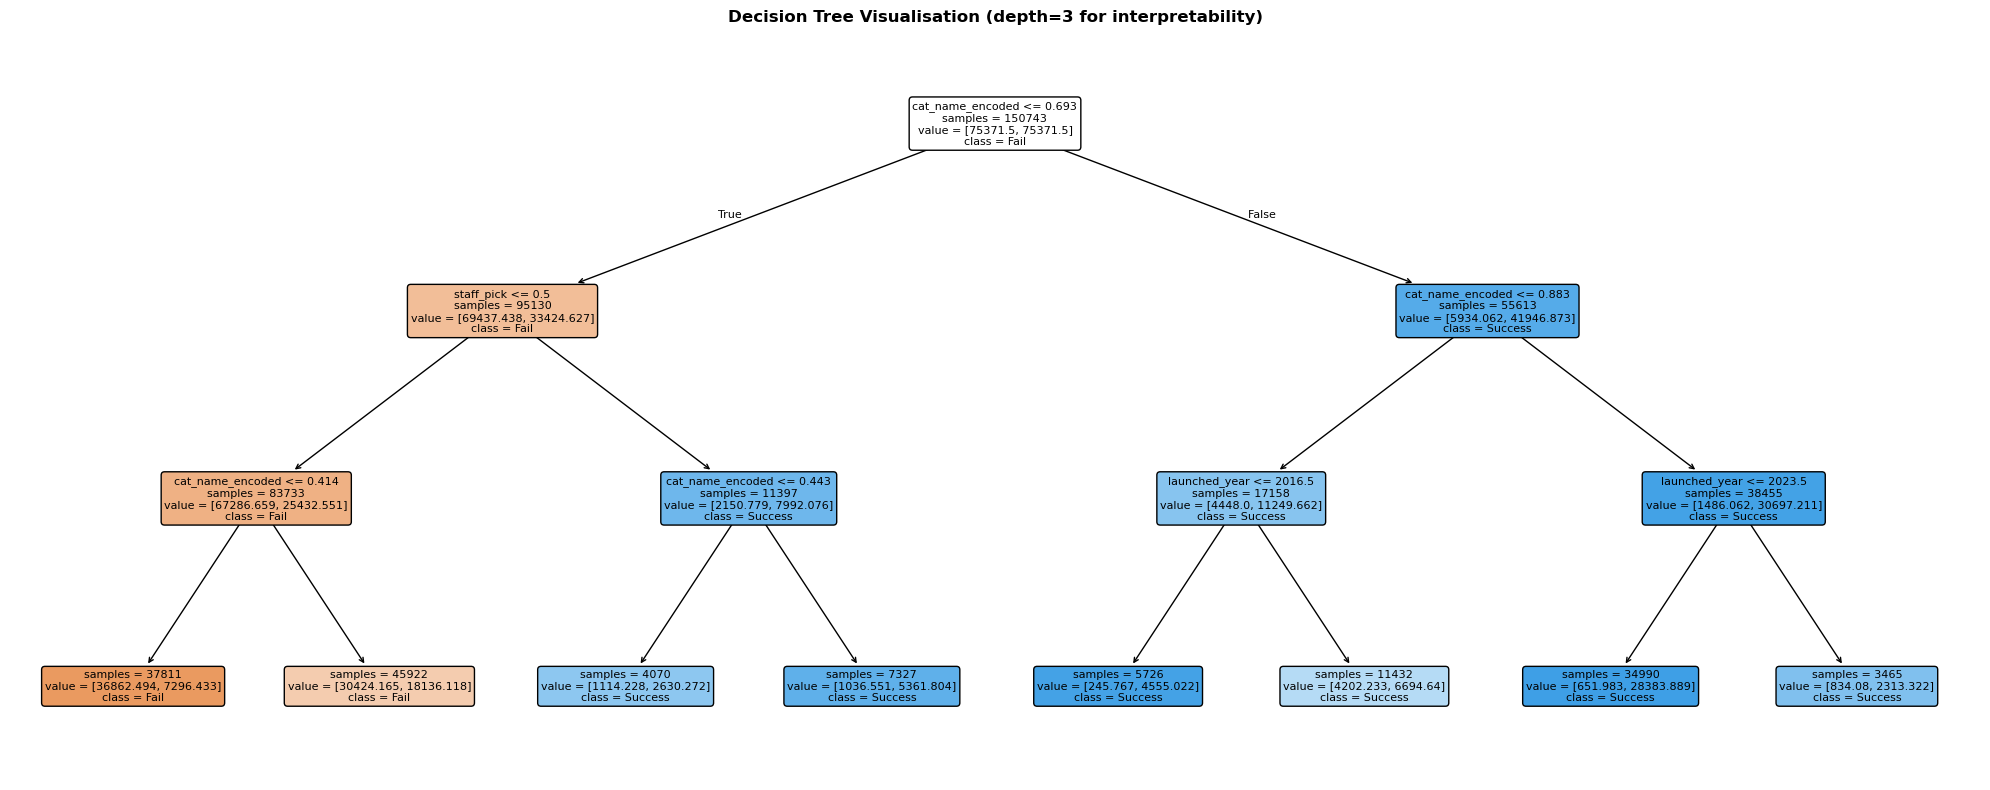

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

depths = [3, 5, 7, 10, 15, None]
dt_cv_scores = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=RANDOM_STATE)
    s  = cross_val_score(dt, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    dt_cv_scores.append(s.mean())
    print(f"  max_depth={str(d):<5}: AUC={s.mean():.4f} ± {s.std():.4f}")

best_depth = depths[np.argmax(dt_cv_scores)]
print(f"\nBest max_depth: {best_depth}")

fig, ax = plt.subplots(figsize=(8, 4))
depth_labels = [str(d) if d is not None else "None" for d in depths]
ax.plot(depth_labels, dt_cv_scores, marker="o", color=SUCCESS_COLOR, linewidth=2)
ax.set_title("Decision Tree — CV ROC-AUC vs max_depth", fontweight="bold")
ax.set_xlabel("max_depth")
ax.set_ylabel("CV ROC-AUC")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "dt_depth_cv.png"), dpi=150, bbox_inches="tight")
plt.show()

best_dt = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE)
best_dt.fit(X_train, y_train)
dt_results = evaluate_model(best_dt, X_test, y_test, "Decision Tree", figures_dir=FIGURES_PATH)

# Visualise tree at depth=3
dt_viz = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=RANDOM_STATE)
dt_viz.fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_viz, feature_names=FEATURE_COLS, class_names=["Fail","Success"],
          filled=True, rounded=True, fontsize=8, ax=ax, impurity=False)
ax.set_title("Decision Tree Visualisation (depth=3 for interpretability)", fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "dt_tree_viz.png"), dpi=150, bbox_inches="tight")
plt.show()

with open(os.path.join(MODELS_PATH, "decision_tree.pkl"), "wb") as f:
    pickle.dump(best_dt, f)


## Model 3 — Random Forest (Core Syllabus Model)

Random Forest is the cornerstone ensemble method covered in this course. It builds many decorrelated decision trees by (a) bootstrapping the training data and (b) randomly selecting a subset of features at each split. The final prediction is the majority vote.

**Key concepts demonstrated:**
- **Out-of-bag (OOB) error**: each tree is trained on ~63% of the data; the remaining 37% provide a free validation estimate without needing a separate validation set.
- **Feature importance**: measured by mean decrease in impurity across all trees.
- **Bias-variance tradeoff**: more trees reduce variance with minimal increase in bias.

We use `RandomizedSearchCV` (faster than GridSearchCV for large search spaces).

Running RandomizedSearchCV for Random Forest (n_iter=20)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}
Best CV AUC: 0.9157
OOB Score: 0.8287 (free validation estimate from unused bootstrap samples)

  Model: Random Forest
  Accuracy        : 0.8262
  Precision       : 0.8354
  Recall          : 0.9326
  F1 (binary)     : 0.8813
  F1 (macro)      : 0.7785
  ROC-AUC         : 0.8861
  PR-AUC          : 0.9405

              precision    recall  f1-score   support

           0       0.80      0.59      0.68     11613
           1       0.84      0.93      0.88     26073

    accuracy                           0.83     37686
   macro avg       0.82      0.76      0.78     37686
weighted avg       0.82      0.83      0.82     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligen

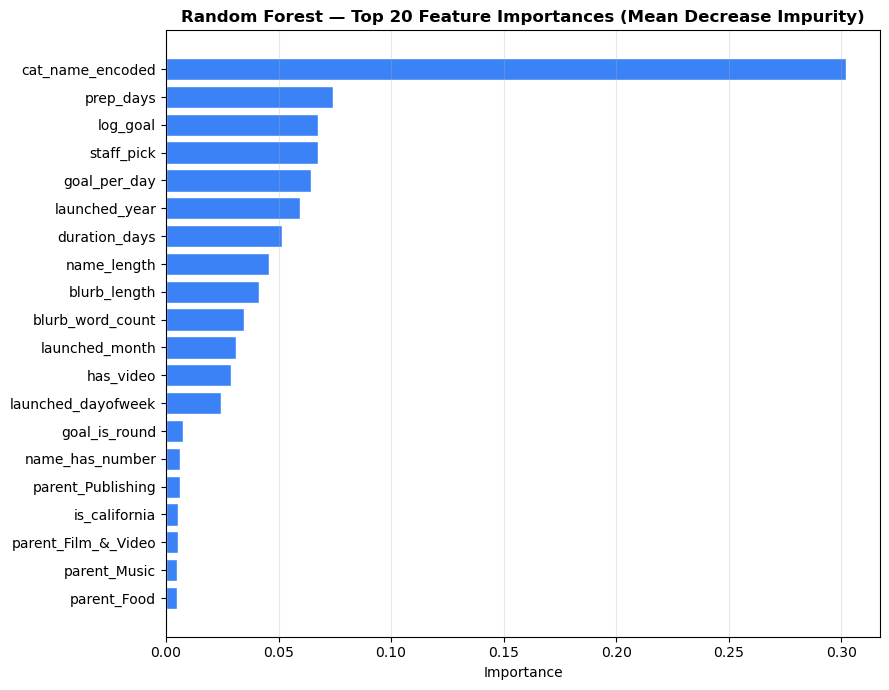


Generating learning curve (this may take a minute)...


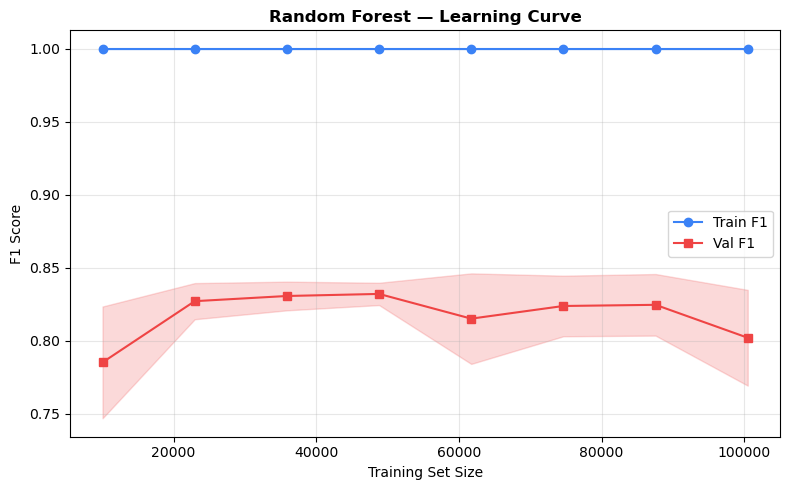

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "n_estimators"   : [100, 200, 300, 500],
    "max_features"   : ["sqrt", "log2", 0.3],
    "max_depth"      : [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 5],
}

print("Running RandomizedSearchCV for Random Forest (n_iter=20)...")
rf_base = RandomForestClassifier(class_weight="balanced", n_jobs=-1,
                                  oob_score=True, random_state=RANDOM_STATE)
rf_search = RandomizedSearchCV(rf_base, rf_param_grid, n_iter=20,
                                cv=skf, scoring="roc_auc", n_jobs=-1,
                                random_state=RANDOM_STATE, verbose=1)
rf_search.fit(X_train, y_train)
print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV AUC: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
print(f"OOB Score: {best_rf.oob_score_:.4f} (free validation estimate from unused bootstrap samples)")

rf_results = evaluate_model(best_rf, X_test, y_test, "Random Forest", figures_dir=FIGURES_PATH)

# Feature importances
importances = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS)
top20_rf    = importances.sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20_rf.index, top20_rf.values, color=SUCCESS_COLOR, edgecolor="white")
ax.set_title("Random Forest — Top 20 Feature Importances (Mean Decrease Impurity)", fontweight="bold")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "rf_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

# Learning curve
print("\nGenerating learning curve (this may take a minute)...")
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train, cv=3, scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color=SUCCESS_COLOR, label="Train F1")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color=SUCCESS_COLOR)
ax.plot(train_sizes, val_scores.mean(axis=1), "s-", color=FAILURE_COLOR, label="Val F1")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color=FAILURE_COLOR)
ax.set_title("Random Forest — Learning Curve", fontweight="bold")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("F1 Score")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "rf_learning_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

with open(os.path.join(MODELS_PATH, "random_forest.pkl"), "wb") as f:
    pickle.dump(best_rf, f)
importances.to_csv(os.path.join(OUTPUTS_PATH, "results", "rf_importances.csv"), header=["importance"])


## Model 4 — Gradient Boosting

Gradient Boosting builds trees **sequentially** — each tree corrects the errors of the previous one by fitting to the residuals. This is the complementary boosting approach to Random Forest's bagging. Boosting generally achieves lower bias at the cost of higher variance risk (overfitting).

Running RandomizedSearchCV for Gradient Boosting (n_iter=15)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2}

  Model: Gradient Boosting
  Accuracy        : 0.8333
  Precision       : 0.8565
  Recall          : 0.9119
  F1 (binary)     : 0.8833
  F1 (macro)      : 0.7958
  ROC-AUC         : 0.8908
  PR-AUC          : 0.9435

              precision    recall  f1-score   support

           0       0.77      0.66      0.71     11613
           1       0.86      0.91      0.88     26073

    accuracy                           0.83     37686
   macro avg       0.81      0.78      0.80     37686
weighted avg       0.83      0.83      0.83     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv


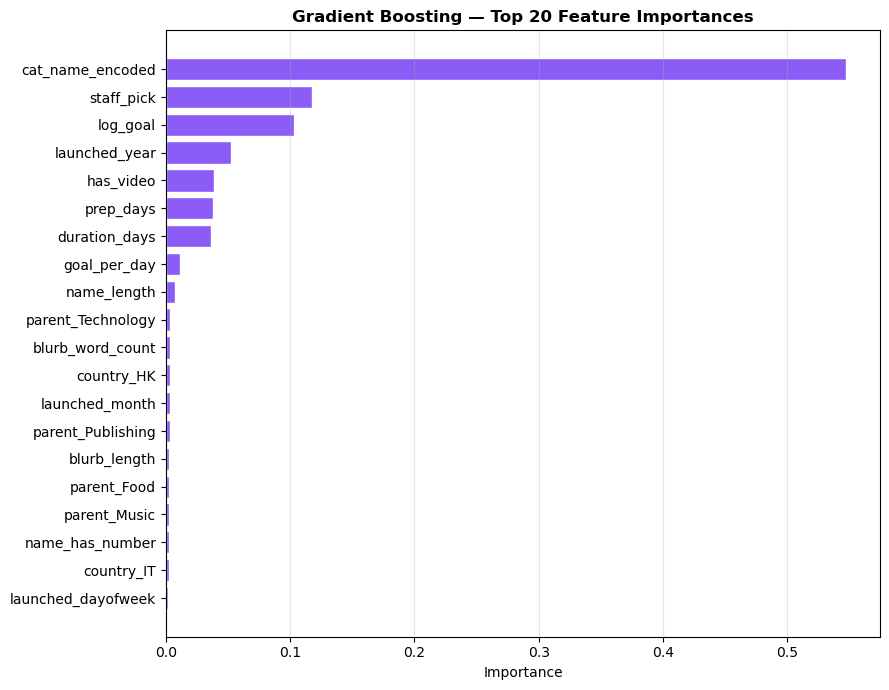

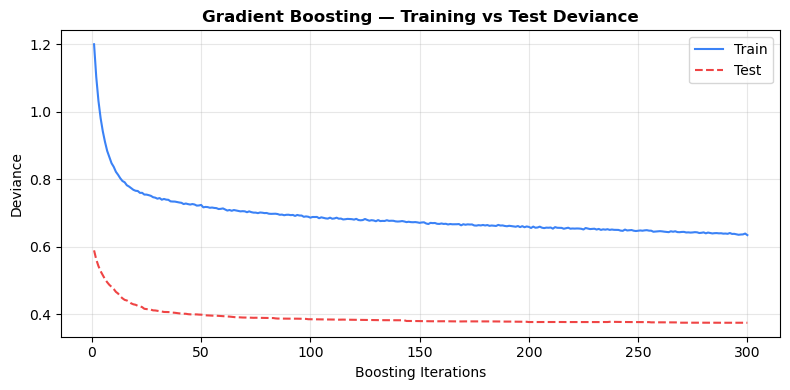

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss

gb_params = {
    "n_estimators" : [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth"    : [2, 3, 4, 5],
    "subsample"    : [0.7, 0.8, 1.0],
}
print("Running RandomizedSearchCV for Gradient Boosting (n_iter=15)...")
gb_search = RandomizedSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                                gb_params, n_iter=15, cv=skf, scoring="roc_auc",
                                n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
gb_search.fit(X_train, y_train)
print(f"\nBest params: {gb_search.best_params_}")
best_gb = gb_search.best_estimator_
gb_results = evaluate_model(best_gb, X_test, y_test, "Gradient Boosting", figures_dir=FIGURES_PATH)

# Feature importances
gb_imp = pd.Series(best_gb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(gb_imp.index, gb_imp.values, color="#8B5CF6", edgecolor="white")
ax.set_title("Gradient Boosting — Top 20 Feature Importances", fontweight="bold")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "gb_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

# Training deviance curve
test_score = np.zeros(best_gb.n_estimators_)
for i, y_pred in enumerate(best_gb.staged_predict_proba(X_test)):
    test_score[i] = log_loss(y_test.values, y_pred)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, best_gb.n_estimators_ + 1), best_gb.train_score_, color=SUCCESS_COLOR, label="Train")
ax.plot(range(1, best_gb.n_estimators_ + 1), test_score, color=FAILURE_COLOR, label="Test", linestyle="--")
ax.set_title("Gradient Boosting — Training vs Test Deviance", fontweight="bold")
ax.set_xlabel("Boosting Iterations")
ax.set_ylabel("Deviance")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "gb_deviance.png"), dpi=150, bbox_inches="tight")
plt.show()

with open(os.path.join(MODELS_PATH, "gradient_boosting.pkl"), "wb") as f:
    pickle.dump(best_gb, f)

## Model 5 — XGBoost

XGBoost is an optimised implementation of gradient boosting with built-in regularisation (L1/L2), missing value handling, and `scale_pos_weight` for class imbalance. It is consistently the top performer in tabular ML competitions.

Running RandomizedSearchCV for XGBoost (n_iter=20)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

  Model: XGBoost
  Accuracy        : 0.8383
  Precision       : 0.8600
  Recall          : 0.9153
  F1 (binary)     : 0.8868
  F1 (macro)      : 0.8020
  ROC-AUC         : 0.8954
  PR-AUC          : 0.9453

              precision    recall  f1-score   support

           0       0.78      0.67      0.72     11613
           1       0.86      0.92      0.89     26073

    accuracy                           0.84     37686
   macro avg       0.82      0.79      0.80     37686
weighted avg       0.83      0.84      0.83     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_mod

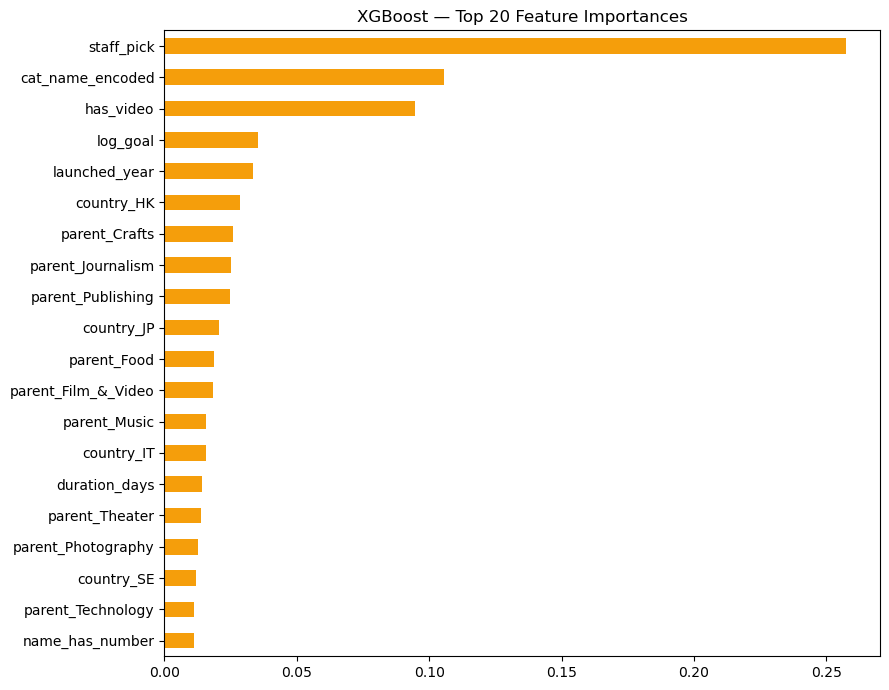

  shap not installed — skipping SHAP plots.


In [14]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — skipping. Install with: pip install xgboost")

if HAS_XGB:
    xgb_params = {
        "n_estimators"    : [100, 200, 500],
        "learning_rate"   : [0.01, 0.05, 0.1],
        "max_depth"       : [3, 5, 7],
        "subsample"       : [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "scale_pos_weight": [1, int((y_train==0).sum() / (y_train==1).sum())],
    }
    print("Running RandomizedSearchCV for XGBoost (n_iter=20)...")
    xgb_base   = XGBClassifier(eval_metric="logloss", use_label_encoder=False,
                                random_state=RANDOM_STATE, n_jobs=-1)
    xgb_search = RandomizedSearchCV(xgb_base, xgb_params, n_iter=20,
                                     cv=skf, scoring="roc_auc", n_jobs=-1,
                                     random_state=RANDOM_STATE, verbose=1)
    xgb_search.fit(X_train, y_train)
    print(f"\nBest params: {xgb_search.best_params_}")
    best_xgb = xgb_search.best_estimator_
    xgb_results = evaluate_model(best_xgb, X_test, y_test, "XGBoost", figures_dir=FIGURES_PATH)

    xgb_imp = pd.Series(best_xgb.feature_importances_, index=FEATURE_COLS)
    xgb_imp.sort_values().tail(20).plot.barh(color="#F59E0B", figsize=(9,7))
    plt.title("XGBoost — Top 20 Feature Importances")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, "xgb_feature_importance.png"), dpi=150, bbox_inches="tight")
    plt.show()
    xgb_imp.to_csv(os.path.join(OUTPUTS_PATH, "results", "xgb_importances.csv"), header=["importance"])

    with open(os.path.join(MODELS_PATH, "xgboost.pkl"), "wb") as f:
        pickle.dump(best_xgb, f)

    # SHAP (if available)
    try:
        import shap
        print("\nGenerating SHAP values (sample of 3000)...")
        sample_idx = np.random.choice(len(X_test), min(3000, len(X_test)), replace=False)
        X_sample   = X_test.iloc[sample_idx]
        explainer  = shap.TreeExplainer(best_xgb)
        shap_vals  = explainer.shap_values(X_sample)
        fig, ax = plt.subplots(figsize=(9, 7))
        shap.summary_plot(shap_vals, X_sample, feature_names=FEATURE_COLS,
                          show=False, plot_size=None)
        plt.title("XGBoost SHAP Summary Plot", fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_PATH, "xgb_shap_summary.png"), dpi=150, bbox_inches="tight")
        plt.show()
        pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": np.abs(shap_vals).mean(0)}).to_csv(
            os.path.join(OUTPUTS_PATH, "results", "shap_importances.csv"), index=False)
    except ImportError:
        print("  shap not installed — skipping SHAP plots.")


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## Model 6 — K-Nearest Neighbours

KNN classifies a new campaign by finding its k nearest training examples and taking the majority class. The intuition: if a campaign is similar to past successful campaigns across all features, it will likely succeed too.

**Computational note:** KNN is O(n) at inference — expensive on 150K rows. We subsample to 30K for tuning, then fit on the full training set.

Tuning KNN on 30K subsample (k=5 to 51, odd only)...
  k= 5: AUC=0.8184
  k= 7: AUC=0.8293
  k= 9: AUC=0.8361
  k=11: AUC=0.8404
  k=13: AUC=0.8427
  k=15: AUC=0.8447
  k=17: AUC=0.8456
  k=19: AUC=0.8463
  k=21: AUC=0.8465
  k=23: AUC=0.8467
  k=25: AUC=0.8464
  k=27: AUC=0.8461
  k=29: AUC=0.8463
  k=31: AUC=0.8462
  k=33: AUC=0.8461
  k=35: AUC=0.8461
  k=37: AUC=0.8461
  k=39: AUC=0.8461
  k=41: AUC=0.8458
  k=43: AUC=0.8451
  k=45: AUC=0.8447
  k=47: AUC=0.8444
  k=49: AUC=0.8442
  k=51: AUC=0.8439

Best k: 23


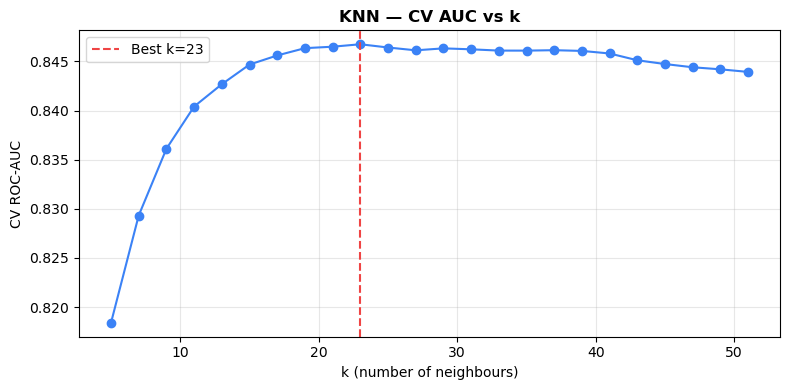

Fitting KNN on full training set...

  Model: KNN
  Accuracy        : 0.7818
  Precision       : 0.7921
  Recall          : 0.9282
  F1 (binary)     : 0.8548
  F1 (macro)      : 0.7081
  ROC-AUC         : 0.8131
  PR-AUC          : 0.8874

              precision    recall  f1-score   support

           0       0.74      0.45      0.56     11613
           1       0.79      0.93      0.85     26073

    accuracy                           0.78     37686
   macro avg       0.76      0.69      0.71     37686
weighted avg       0.78      0.78      0.76     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv


In [6]:
from sklearn.neighbors import KNeighborsClassifier

# Subsample for tuning speed
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), 30000, replace=False)
X_knn_tune = X_train.iloc[sample_idx]
y_knn_tune = y_train.iloc[sample_idx]

print("Tuning KNN on 30K subsample (k=5 to 51, odd only)...")
ks      = list(range(5, 52, 2))
knn_auc = []
for k in ks:
    scaler = StandardScaler()
    Xsc    = scaler.fit_transform(X_knn_tune)
    s      = cross_val_score(KNeighborsClassifier(n_neighbors=k, n_jobs=-1),
                              Xsc, y_knn_tune, cv=3, scoring="roc_auc")
    knn_auc.append(s.mean())
    print(f"  k={k:2d}: AUC={s.mean():.4f}")

best_k = ks[np.argmax(knn_auc)]
print(f"\nBest k: {best_k}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, knn_auc, marker="o", color=SUCCESS_COLOR)
ax.axvline(best_k, color=FAILURE_COLOR, linestyle="--", label=f"Best k={best_k}")
ax.set_title("KNN — CV AUC vs k", fontweight="bold")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("CV ROC-AUC")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "knn_k_selection.png"), dpi=150, bbox_inches="tight")
plt.show()

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
])
print("Fitting KNN on full training set...")
knn_pipeline.fit(X_train, y_train)
knn_results = evaluate_model(knn_pipeline, X_test, y_test, "KNN", figures_dir=FIGURES_PATH)

with open(os.path.join(MODELS_PATH, "knn.pkl"), "wb") as f:
    pickle.dump(knn_pipeline, f)


## Model 7 — Naive Bayes

GaussianNB assumes all features are independent and normally distributed given the class label. Both assumptions are clearly violated here (goal and category are correlated; features are not Gaussian). Nevertheless it provides a fast probabilistic baseline.

In [7]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
cv_report(nb_model, X_train, y_train, "Naive Bayes")
nb_model.fit(X_train, y_train)
nb_results = evaluate_model(nb_model, X_test, y_test, "Naive Bayes", figures_dir=FIGURES_PATH)

print("\nNote: GaussianNB assumes feature independence — clearly violated here.")
print("      (e.g. log_goal and cat_name_encoded are correlated)")
print("      Despite this, it often achieves surprisingly reasonable AUC.")

with open(os.path.join(MODELS_PATH, "naive_bayes.pkl"), "wb") as f:
    pickle.dump(nb_model, f)


  [Naive Bayes] CV F1 : 0.7966 ± 0.0017
  [Naive Bayes] CV AUC: 0.8426 ± 0.0014

  Model: Naive Bayes
  Accuracy        : 0.7222
  Precision       : 0.7173
  Recall          : 0.9877
  F1 (binary)     : 0.8311
  F1 (macro)      : 0.5249
  ROC-AUC         : 0.8213
  PR-AUC          : 0.9038

              precision    recall  f1-score   support

           0       0.82      0.13      0.22     11613
           1       0.72      0.99      0.83     26073

    accuracy                           0.72     37686
   macro avg       0.77      0.56      0.52     37686
weighted avg       0.75      0.72      0.64     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv

Note: GaussianNB assumes feature independence — clearly violated here.
      (e.g. log_goal and cat_name_encoded are correlated)
      Despite this, it often

## Model 8 — Linear SVC

Support Vector Machines find the maximum-margin hyperplane separating classes. We use LinearSVC (instead of full kernel SVC) for computational efficiency on 150K rows. **SVMs are sensitive to feature scale** — we always apply StandardScaler first.

In [8]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svc_Cs = [0.01, 0.1, 1, 10]
svc_auc = []
print("Tuning LinearSVC C parameter...")
for C in svc_Cs:
    svc_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LinearSVC(C=C, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)),
    ])
    s = cross_val_score(svc_pipe, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1)
    svc_auc.append(s.mean())
    print(f"  C={C}: AUC={s.mean():.4f} ± {s.std():.4f}")

best_C = svc_Cs[np.argmax(svc_auc)]
print(f"\nBest C: {best_C}")

# Calibrate to get probabilities for ROC/PR curves
svc_calibrated = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  CalibratedClassifierCV(
        LinearSVC(C=best_C, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
        cv=3)),
])
svc_calibrated.fit(X_train, y_train)
svc_results = evaluate_model(svc_calibrated, X_test, y_test, "Linear SVC", figures_dir=FIGURES_PATH)

with open(os.path.join(MODELS_PATH, "linear_svc.pkl"), "wb") as f:
    pickle.dump(svc_calibrated, f)


Tuning LinearSVC C parameter...
  C=0.01: AUC=0.8902 ± 0.0016
  C=0.1: AUC=0.8902 ± 0.0016
  C=1: AUC=0.8902 ± 0.0016
  C=10: AUC=0.8902 ± 0.0016

Best C: 0.1

  Model: Linear SVC
  Accuracy        : 0.7848
  Precision       : 0.7976
  Recall          : 0.9232
  F1 (binary)     : 0.8558
  F1 (macro)      : 0.7158
  ROC-AUC         : 0.8280
  PR-AUC          : 0.9086

              precision    recall  f1-score   support

           0       0.73      0.47      0.58     11613
           1       0.80      0.92      0.86     26073

    accuracy                           0.78     37686
   macro avg       0.77      0.70      0.72     37686
weighted avg       0.78      0.78      0.77     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv


## Model 9 — Voting Ensemble

Combines Logistic Regression + Random Forest + XGBoost (if available) using **soft voting**: each model predicts class probabilities, and the final prediction is the average probability. This works best when the constituent models make *different* errors — diversity is key.

In [15]:
from sklearn.ensemble import VotingClassifier

estimators_for_voting = [
    ("lr",  Pipeline([("scaler", StandardScaler()),
                       ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))])),
    ("rf",  best_rf),
]
if HAS_XGB:
    estimators_for_voting.append(("xgb", best_xgb))

voting_model = VotingClassifier(estimators=estimators_for_voting, voting="soft", n_jobs=-1)
print(f"Fitting Voting Ensemble with {len(estimators_for_voting)} base models...")
voting_model.fit(X_train, y_train)
voting_results = evaluate_model(voting_model, X_test, y_test, "Voting Ensemble", figures_dir=FIGURES_PATH)

with open(os.path.join(MODELS_PATH, "voting_ensemble.pkl"), "wb") as f:
    pickle.dump(voting_model, f)


Fitting Voting Ensemble with 3 base models...

  Model: Voting Ensemble
  Accuracy        : 0.8278
  Precision       : 0.8468
  Recall          : 0.9170
  F1 (binary)     : 0.8805
  F1 (macro)      : 0.7862
  ROC-AUC         : 0.8845
  PR-AUC          : 0.9407

              precision    recall  f1-score   support

           0       0.77      0.63      0.69     11613
           1       0.85      0.92      0.88     26073

    accuracy                           0.83     37686
   macro avg       0.81      0.77      0.79     37686
weighted avg       0.82      0.83      0.82     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv


## Model 10 — Stacking Ensemble

Stacking goes further than voting: it trains a **meta-learner** (Logistic Regression) on the out-of-fold predictions of the base learners. Instead of averaging probabilities, the meta-learner *learns* the optimal way to combine base model outputs. This can capture which base model is most reliable in which region of the feature space.

In [16]:
from sklearn.ensemble import StackingClassifier

base_learners = [
    ("lr", Pipeline([("sc", StandardScaler()),
                      ("m", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))])),
    ("rf", RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ("dt", best_dt if 'best_dt' in dir() else DecisionTreeClassifier(max_depth=7, class_weight="balanced", random_state=RANDOM_STATE)),
]
if HAS_XGB:
    base_learners.append(("xgb", XGBClassifier(n_estimators=100, eval_metric="logloss",
                                                 use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1)))

meta_learner = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
stacking_model = StackingClassifier(
    estimators=base_learners, final_estimator=meta_learner,
    cv=3, passthrough=False, n_jobs=-1
)
print("Fitting Stacking Ensemble...")
stacking_model.fit(X_train, y_train)
stacking_results = evaluate_model(stacking_model, X_test, y_test, "Stacking Ensemble", figures_dir=FIGURES_PATH)

with open(os.path.join(MODELS_PATH, "stacking_ensemble.pkl"), "wb") as f:
    pickle.dump(stacking_model, f)


Fitting Stacking Ensemble...


[17:14:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[17:14:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[17:14:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




  Model: Stacking Ensemble
  Accuracy        : 0.7937
  Precision       : 0.8103
  Recall          : 0.9164
  F1 (binary)     : 0.8601
  F1 (macro)      : 0.7339
  ROC-AUC         : 0.8325
  PR-AUC          : 0.9024

              precision    recall  f1-score   support

           0       0.73      0.52      0.61     11613
           1       0.81      0.92      0.86     26073

    accuracy                           0.79     37686
   macro avg       0.77      0.72      0.73     37686
weighted avg       0.79      0.79      0.78     37686


  Plots saved to: ../outputs/figures
  Results appended to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/outputs/results/all_model_results.csv


## Final Model Comparison

Load all results, compare models visually, plot unified ROC and PR curves.

In [17]:
import os
results_csv = os.path.join(OUTPUTS_PATH, "results", "all_model_results.csv")
results_df  = pd.read_csv(results_csv).sort_values("roc_auc", ascending=False)
print("\nAll models ranked by ROC-AUC:")
print(results_df[["model","roc_auc","f1_binary","precision","recall","pr_auc"]].to_string(index=False))



All models ranked by ROC-AUC:
              model  roc_auc  f1_binary  precision  recall  pr_auc
            XGBoost   0.8954     0.8868     0.8600  0.9153  0.9453
  Gradient Boosting   0.8908     0.8833     0.8565  0.9119  0.9435
      Random Forest   0.8861     0.8813     0.8354  0.9326  0.9405
    Voting Ensemble   0.8845     0.8805     0.8468  0.9170  0.9407
      Decision Tree   0.8454     0.8489     0.8684  0.8302  0.9005
  Stacking Ensemble   0.8325     0.8601     0.8103  0.9164  0.9024
Logistic Regression   0.8285     0.8490     0.8238  0.8758  0.9086
         Linear SVC   0.8280     0.8558     0.7976  0.9232  0.9086
        Naive Bayes   0.8213     0.8311     0.7173  0.9877  0.9038
                KNN   0.8131     0.8548     0.7921  0.9282  0.8874


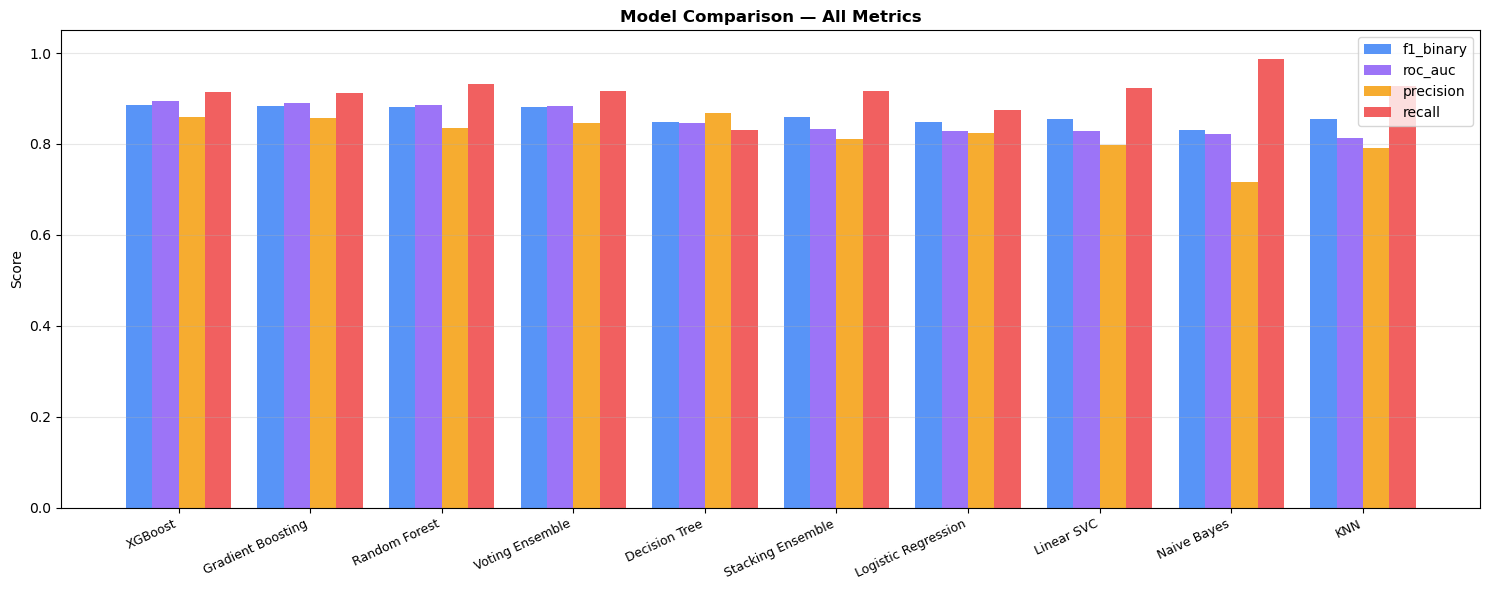

In [18]:
# Grouped bar chart
metrics = ["f1_binary", "roc_auc", "precision", "recall"]
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(15, 6))
colors_bar = [SUCCESS_COLOR, "#8B5CF6", "#F59E0B", FAILURE_COLOR]
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df["model"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — All Metrics", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "model_comparison_bar.png"), dpi=150, bbox_inches="tight")
plt.show()


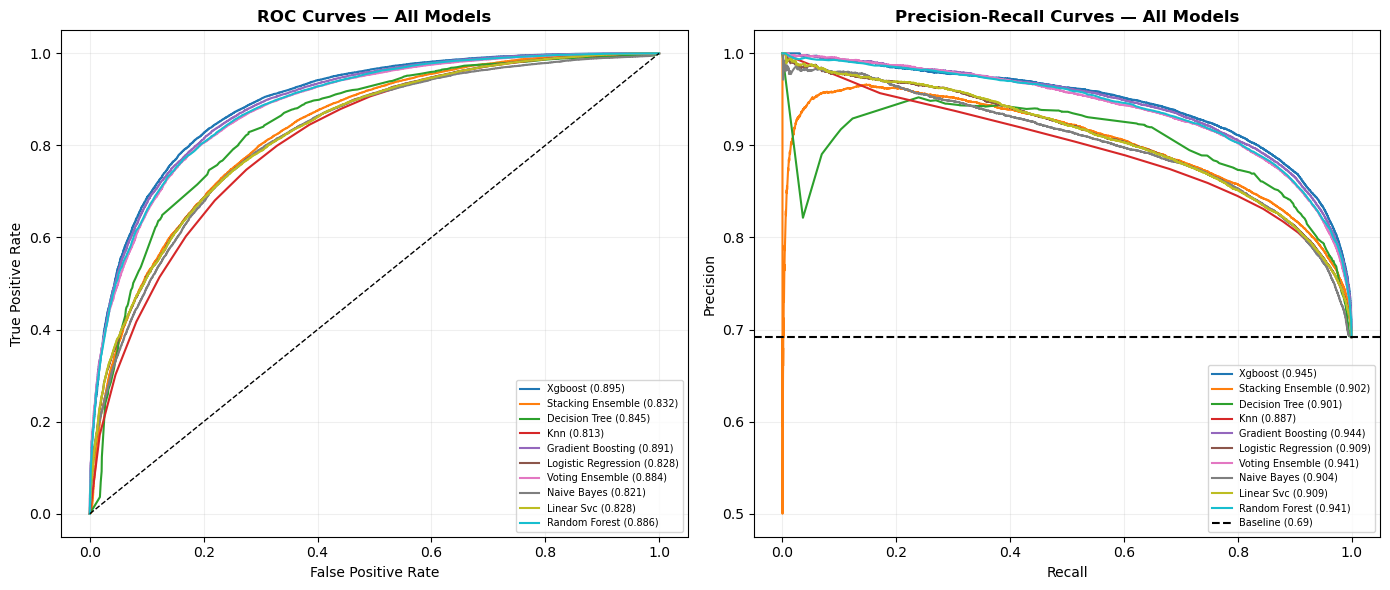

In [19]:
# Combined ROC curves
from sklearn.metrics import roc_curve, precision_recall_curve
model_objects = {}
for fname in os.listdir(MODELS_PATH):
    if fname.endswith(".pkl"):
        name = fname.replace(".pkl","").replace("_"," ").title()
        with open(os.path.join(MODELS_PATH, fname), "rb") as f:
            model_objects[name] = pickle.load(f)

palette_colors = plt.cm.tab10(np.linspace(0, 1, len(model_objects)))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (mname, mobj), color in zip(model_objects.items(), palette_colors):
    try:
        if hasattr(mobj, "predict_proba"):
            probs = mobj.predict_proba(X_test)[:,1]
        elif hasattr(mobj, "decision_function"):
            raw = mobj.decision_function(X_test)
            probs = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
        else:
            continue
        from sklearn.metrics import roc_auc_score, average_precision_score
        auc = roc_auc_score(y_test, probs)
        apr = average_precision_score(y_test, probs)
        fpr, tpr, _ = roc_curve(y_test, probs)
        prc, rec, _ = precision_recall_curve(y_test, probs)
        axes[0].plot(fpr, tpr, color=color, lw=1.5, label=f"{mname} ({auc:.3f})")
        axes[1].plot(rec, prc, color=color, lw=1.5, label=f"{mname} ({apr:.3f})")
    except Exception as e:
        print(f"  [{mname}] skipped: {e}")

axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_title("ROC Curves — All Models", fontweight="bold")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=7, loc="lower right"); axes[0].grid(alpha=0.2)

axes[1].axhline(y_test.mean(), color="k", linestyle="--", label=f"Baseline ({y_test.mean():.2f})")
axes[1].set_title("Precision-Recall Curves — All Models", fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "all_models_roc_pr.png"), dpi=150, bbox_inches="tight")
plt.show()


## Threshold Analysis on Best Model

The 0.5 decision threshold is arbitrary. The optimal threshold depends entirely on the business context:

- **High recall goal** (don't miss any likely-to-succeed campaign): lower the threshold → more campaigns flagged as success → more false positives accepted.
- **High precision goal** (only flag campaigns you're very confident about): raise the threshold → fewer campaigns flagged → fewer false positives.

This connects to the asymmetry of error costs: a missed great campaign (false negative) costs Kickstarter a featured failure to support; an incorrectly featured bad campaign (false positive) wastes editorial attention.

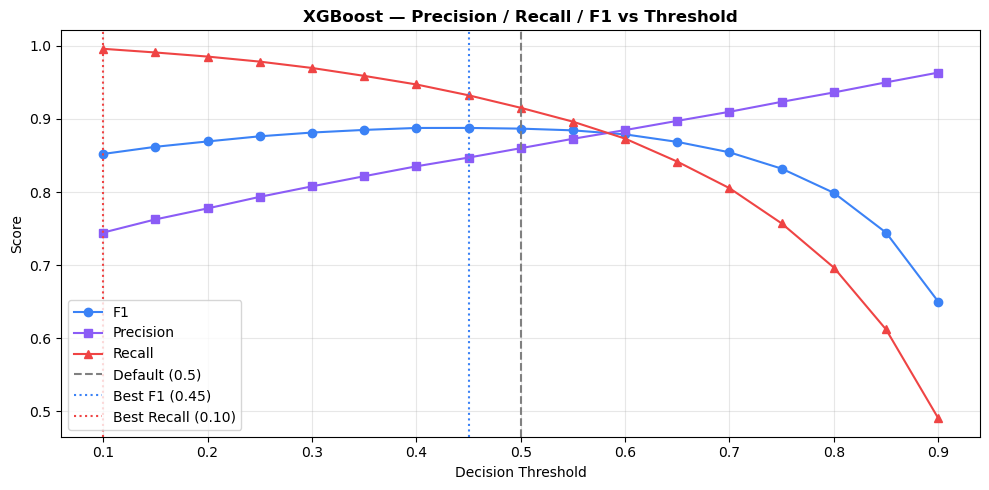

Default threshold (0.50): F1=0.8868
Best F1 threshold (0.45): F1=0.8877
Best Recall threshold (0.10): Recall=0.9959

Notebook 04 complete. Proceed to 05_results_and_reflection.ipynb


In [25]:
from sklearn.metrics import precision_score, recall_score

# Use best model by AUC
best_model_name = results_df.iloc[0]["model"]
best_model_file = best_model_name.lower().replace(" ","_") + ".pkl"
best_model_path = os.path.join(MODELS_PATH, best_model_file)

try:
    with open(best_model_path, "rb") as f:
        best_model_obj = pickle.load(f)
    if hasattr(best_model_obj, "predict_proba"):
        best_probs = best_model_obj.predict_proba(X_test)[:,1]
    else:
        best_probs = best_model_obj.decision_function(X_test)
        best_probs = (best_probs - best_probs.min()) / (best_probs.max() - best_probs.min())
except Exception:
    best_probs = best_rf.predict_proba(X_test)[:,1]
    best_model_name = "Random Forest"

thresholds = np.arange(0.1, 0.91, 0.05)
th_f1, th_prec, th_rec = [], [], []
for t in thresholds:
    preds = (best_probs >= t).astype(int)
    th_f1.append(f1_score(y_test, preds, zero_division=0))
    th_prec.append(precision_score(y_test, preds, zero_division=0))
    th_rec.append(recall_score(y_test, preds, zero_division=0))

best_f1_thresh  = thresholds[np.argmax(th_f1)]
best_rec_thresh = thresholds[np.argmax(th_rec)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, th_f1,   "o-", color=SUCCESS_COLOR,  label="F1")
ax.plot(thresholds, th_prec, "s-", color="#8B5CF6",       label="Precision")
ax.plot(thresholds, th_rec,  "^-", color=FAILURE_COLOR,   label="Recall")
ax.axvline(0.5,            color="grey", linestyle="--",  label="Default (0.5)")
ax.axvline(best_f1_thresh, color=SUCCESS_COLOR, linestyle=":", label=f"Best F1 ({best_f1_thresh:.2f})")
ax.axvline(best_rec_thresh,color=FAILURE_COLOR, linestyle=":", label=f"Best Recall ({best_rec_thresh:.2f})")
ax.set_title(f"{best_model_name} — Precision / Recall / F1 vs Threshold", fontweight="bold")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "threshold_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Default threshold (0.50): F1={th_f1[np.where(thresholds >= 0.5)[0][0]]:.4f}")
print(f"Best F1 threshold ({best_f1_thresh:.2f}): F1={max(th_f1):.4f}")
print(f"Best Recall threshold ({best_rec_thresh:.2f}): Recall={max(th_rec):.4f}")
print("\nNotebook 04 complete. Proceed to 05_results_and_reflection.ipynb")
